<a href="https://colab.research.google.com/github/Vaishnavi-Junghare/ML/blob/main/ml_pract10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ml lab 10
vaishnavi junghare(cs23024)

aim: to perform hierachical clustering using Agglomerativ method and interprint dendograms for cluster formation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path= "/content/drive/MyDrive/ml_dataset/Mall_Customers.csv"
df=pd.read_csv(path)
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
X=df[["Annual Income (k$)","Spending Score (1-100)"]]

In [ ]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

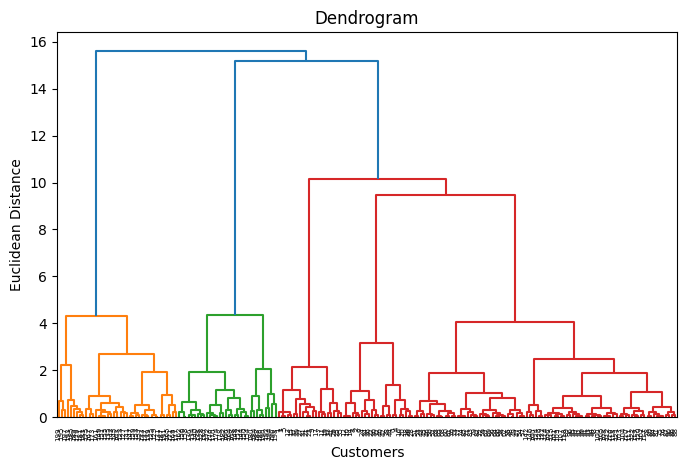

In [ ]:
plt.figure(figsize=(8,5))
dendrogram(linkage(X_scaled,method="ward"))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

In [ ]:
hc=AgglomerativeClustering(n_clusters=5,metric="euclidean",linkage="ward")
clusters=hc.fit_predict(X_scaled)

In [ ]:
df['clusters']=clusters
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   clusters  
0         4  
1         3  
2         4  
3         3  
4         4  


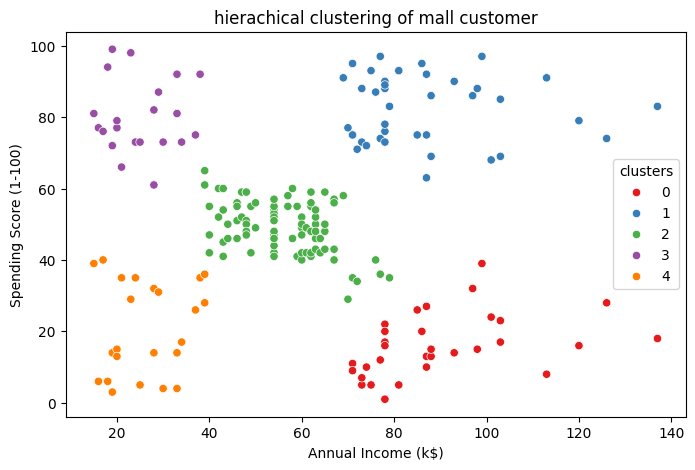

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Annual Income (k$)",y="Spending Score (1-100)",hue="clusters",data=df,palette='Set1')
plt.title("hierachical clustering of mall customer")
plt.show()